In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from db_connect import get_engine


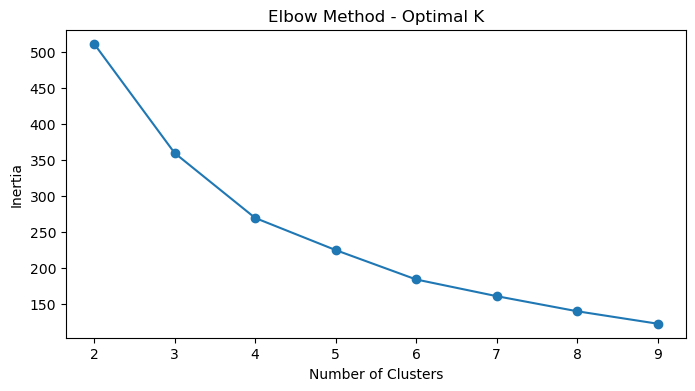

In [2]:
engine=get_engine()
#create our dataframe from our columsn
df=pd.read_sql("SELECT availability, performance, quality, oee, downtime FROM silver_shifts", engine)

features=["availability", "performance", "quality", "oee"]

#create our X variable, features go into an x matrix
X=df[features]

#time to normalize create scalar

scaler=StandardScaler()
#this will center each column areoung mean=0,std=1
X_scaled=scaler.fit_transform(X)

#create lists to hold results for each k
inertias=[]
for k in range(2,10):#2 to 10 clusters

    km_test=KMeans(n_clusters=k,random_state=42)
    km_test.fit(X_scaled) #fit the model to scaled data
    #append resulets to list
    inertias.append(km_test.inertia_) #run kmean with clusertes and measure how tight clusters are with inertia then appen

## create figure for the elbow plot
plt.figure(figsize=(8, 4))

## plot k values on x axis and inertia on y axis
plt.plot(range(2, 10), inertias, marker='o')

plt.title("Elbow Method - Optimal K")  ## chart title
plt.xlabel("Number of Clusters")       ## x axis label
plt.ylabel("Inertia")                  ## y axis label
plt.show()               
    
    
    


In [ ]:
##optimal clusters is around 3 as as the slope flattens closer to 8

In [3]:
## Test 1 - invalid intervals
df_invalid = pd.read_sql("SELECT COUNT(*) as invalid FROM bronze_events WHERE start_time >= end_time", engine)
print("Invalid intervals:", df_invalid["invalid"][0])

Invalid intervals: 0


In [4]:
## Test 2 - events per shift
df_shifts = pd.read_sql("SELECT shift, COUNT(*) as events FROM bronze_events GROUP BY shift ORDER BY shift LIMIT 10", engine)
print("\nEvents per shift (first 10):")
print(df_shifts)


Events per shift (first 10):
   shift  events
0      1      46
1      2      54
2      3      51
3      4      46
4      5      55
5      6      53
6      7      44
7      8      54
8      9      57
9     10      41


In [5]:
## Test 3 - event type stats
df_types = pd.read_sql("SELECT event_type, MIN(start_time) as earliest, MAX(start_time) as latest, AVG(duration) as avg_duration FROM bronze_events GROUP BY event_type", engine)
print("\nEvent type stats:")
print(df_types)



Event type stats:
   event_type  earliest  latest  avg_duration
0  minor_stop       2.0   478.0      1.049825
1  speed_loss       2.0   476.0      3.982622
2         jam       2.0   470.0     30.237762
3         cip       2.0   428.0     45.000000
4  changeover       2.0   450.0     28.897535


In [6]:
## Test 4 - events per stage
df_stages = pd.read_sql("SELECT stage, COUNT(*) as event_count FROM bronze_events GROUP BY stage", engine)
print("\nEvents per stage:")
print(df_stages)


Events per stage:
       stage  event_count
0    Filling         1646
1    Sealing         1612
2  Packaging         1532


In [7]:
## Test 5 - severity distribution
df_severity = pd.read_sql("SELECT severity, COUNT(*) as count FROM bronze_events GROUP BY severity", engine)
print("\nSeverity distribution:")
print(df_severity)


Severity distribution:
  severity  count
0   Medium   1612
1      Low   2318
2     High    860


In [3]:
from intervaltree import IntervalTree

engine = get_engine()

## define peak production hours — minutes 120 to 360 (hours 2-6 of shift)
PEAK_START = 120
PEAK_END = 360

## read all events from bronze_events
df_events = pd.read_sql("SELECT * FROM bronze_events", engine)

## build one IntervalTree per stage
for stage in ["Filling", "Sealing", "Packaging"]:
    ## filter events for this stage
    stage_events = df_events[df_events["stage"] == stage]
    
    ## build the IntervalTree using zip — faster than iterrows
    tree = IntervalTree()
    for start, end, event in zip(stage_events["start_time"], 
                                  stage_events["end_time"], 
                                  stage_events["event_type"]):
        tree[start:end] = event
    
    ## query — which events overlap with peak hours?
    overlapping = tree[PEAK_START:PEAK_END]
    
    print(f"\n{stage} — {len(overlapping)} events overlap peak hours")
    for interval in list(overlapping)[:5]:
        print(f"  {interval.data}: {interval.begin:.1f} → {interval.end:.1f} min")


Filling — 891 events overlap peak hours
  speed_loss: 248.0 → 252.4 min
  speed_loss: 212.0 → 217.0 min
  cip: 294.0 → 339.0 min
  speed_loss: 138.0 → 143.0 min
  minor_stop: 170.0 → 170.4 min

Sealing — 844 events overlap peak hours
  speed_loss: 158.0 → 162.4 min
  jam: 258.0 → 264.0 min
  minor_stop: 202.0 → 202.4 min
  speed_loss: 324.0 → 328.6 min
  jam: 306.0 → 340.0 min

Packaging — 824 events overlap peak hours
  speed_loss: 276.0 → 279.8 min
  minor_stop: 170.0 → 171.3 min
  jam: 286.0 → 344.0 min
  minor_stop: 204.0 → 204.7 min
  speed_loss: 244.0 → 248.8 min


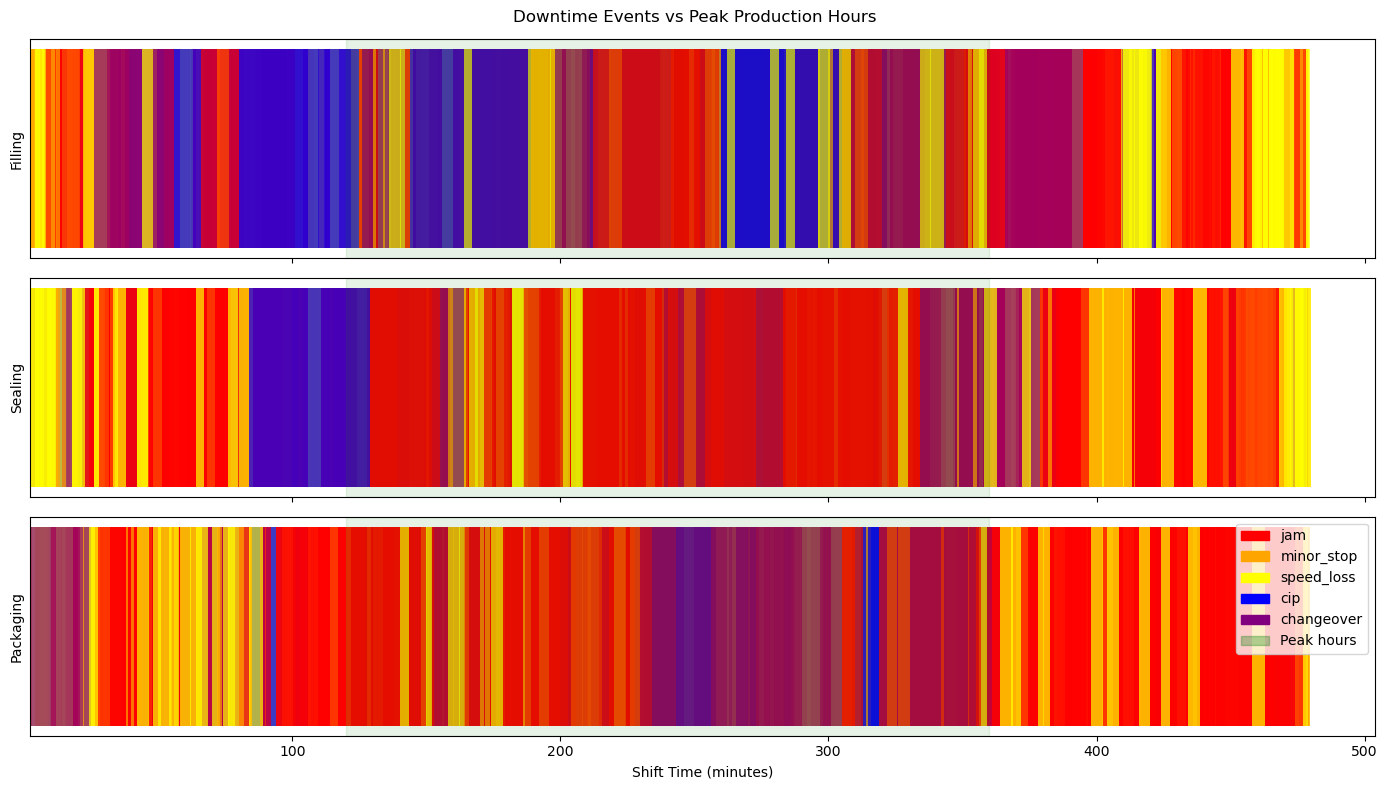

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## color map for event types
colors = {
    "jam": "red",
    "minor_stop": "orange",
    "speed_loss": "yellow",
    "cip": "blue",
    "changeover": "purple"
}

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for ax, stage in zip(axes, ["Filling", "Sealing", "Packaging"]):
    stage_events = df_events[df_events["stage"] == stage]
    
    ## plot each event as a horizontal bar
    for start, end, event in zip(stage_events["start_time"],
                                  stage_events["end_time"],
                                  stage_events["event_type"]):
        ax.barh(0, end - start, left=start, height=0.4,
                color=colors.get(event, "gray"), alpha=0.7)
    
    ## shade peak production hours
    ax.axvspan(PEAK_START, PEAK_END, alpha=0.1, color="green", label="Peak hours")
    ax.set_ylabel(stage)
    ax.set_yticks([])

## legend
patches = [mpatches.Patch(color=v, label=k) for k, v in colors.items()]
patches.append(mpatches.Patch(color="green", alpha=0.3, label="Peak hours"))
plt.legend(handles=patches, loc="upper right")
plt.xlabel("Shift Time (minutes)")
plt.suptitle("Downtime Events vs Peak Production Hours")
plt.tight_layout()
plt.show()

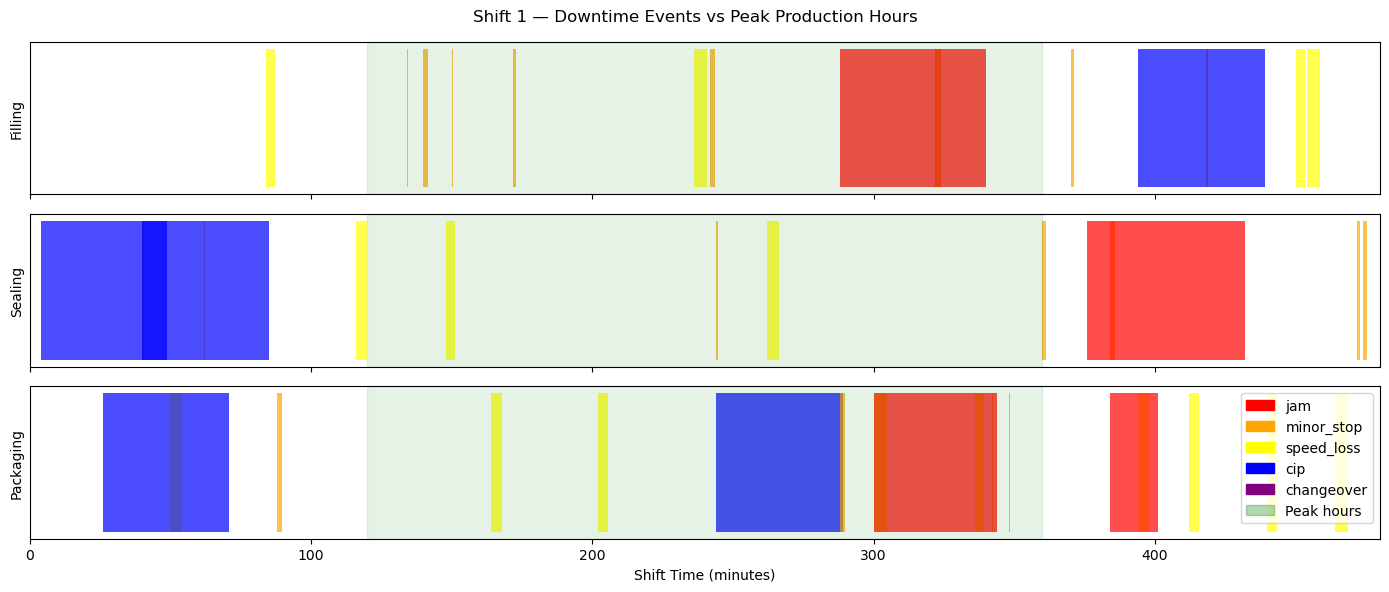

In [5]:
## filter to shift 1 only for clarity
shift_num = 1
df_shift1 = df_events[df_events["shift"] == shift_num]

fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)

for ax, stage in zip(axes, ["Filling", "Sealing", "Packaging"]):
    stage_events = df_shift1[df_shift1["stage"] == stage]
    
    for start, end, event in zip(stage_events["start_time"],
                                  stage_events["end_time"],
                                  stage_events["event_type"]):
        ax.barh(0, end - start, left=start, height=0.4,
                color=colors.get(event, "gray"), alpha=0.7)
    
    ## shade peak production hours
    ax.axvspan(PEAK_START, PEAK_END, alpha=0.1, color="green")
    ax.set_ylabel(stage)
    ax.set_yticks([])
    ax.set_xlim(0, 480)

patches = [mpatches.Patch(color=v, label=k) for k, v in colors.items()]
patches.append(mpatches.Patch(color="green", alpha=0.3, label="Peak hours"))
plt.legend(handles=patches, loc="upper right")
plt.xlabel("Shift Time (minutes)")
plt.suptitle(f"Shift {shift_num} — Downtime Events vs Peak Production Hours")
plt.tight_layout()
plt.show()